In [77]:
import tensorflow

In [78]:
print(tensorflow.__version__)

2.20.0


In [91]:
#mounting the google drive for importing the data
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [92]:
!1s gdrive/MyDrive

/bin/bash: line 1: 1s: command not found


In [94]:
! unzip gdrive/MyDrive/pneumonia-xray-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/normal/IM-0435-0001-0001.jpeg  
  inflating: train/normal/IM-0435-0001.jpeg  
  inflating: train/normal/IM-0437-0001-0001.jpeg  
  inflating: train/normal/IM-0437-0001-0002.jpeg  
  inflating: train/normal/IM-0437-0001.jpeg  
  inflating: train/normal/IM-0438-0001.jpeg  
  inflating: train/normal/IM-0439-0001-0001.jpeg  
  inflating: train/normal/IM-0439-0001-0002.jpeg  
  inflating: train/normal/IM-0439-0001.jpeg  
  inflating: train/normal/IM-0440-0001.jpeg  
  inflating: train/normal/IM-0441-0001.jpeg  
  inflating: train/normal/IM-0442-0001.jpeg  
  inflating: train/normal/IM-0444-0001.jpeg  
  inflating: train/normal/IM-0445-0001.jpeg  
  inflating: train/normal/IM-0446-0001.jpeg  
  inflating: train/normal/IM-0447-0001.jpeg  
  inflating: train/normal/IM-0448-0001.jpeg  
  inflating: train/normal/IM-0449-0001.jpeg  
  inflating: train/normal/IM-0450-0001.jpeg  
  inflating: train/normal/IM-0451-0001.jpeg  
  in

In [95]:
#importing the libraries I
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [96]:
DataDir = r"train/"

In [97]:
CATEGORIES = ["normal", "opacity"]

In [98]:
! ls test

normal	opacity


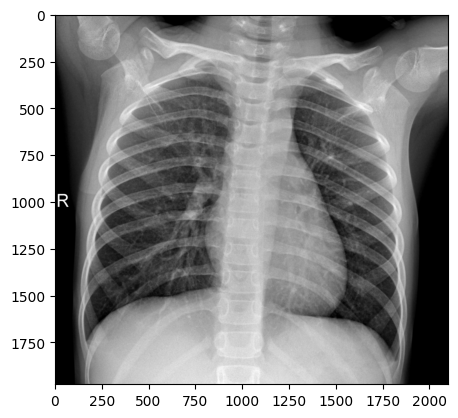

In [99]:
# converting the images into grayscale

for i in CATEGORIES:
    path = os.path.join(DataDir, i)

    for img in os.listdir(path):

        img_array = cv2.imread(
            os.path.join(path, img),
            cv2.IMREAD_GRAYSCALE
        )

        plt.imshow(img_array, cmap='gray')
        plt.show()

        break

    break

In [100]:
img_size = 100

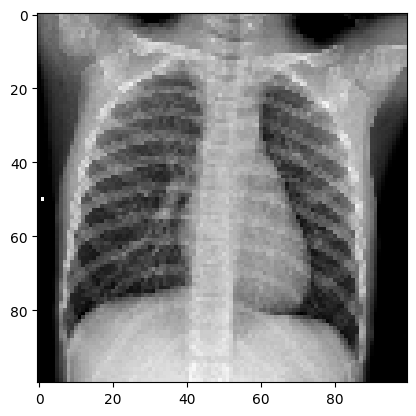

In [101]:
#image after resize and gray scale
new_array=cv2.resize(img_array, (img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [102]:
training_data=[]

In [103]:
def create_training_data():

    for i in CATEGORIES:

        path = os.path.join(DataDir, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):

            try:
                img_array = cv2.imread(
                    os.path.join(path, img),
                    cv2.IMREAD_GRAYSCALE
                )

                new_array = cv2.resize(
                    img_array,
                    (img_size, img_size)
                )

                training_data.append(
                    [new_array, class_num]
                )

            except Exception as e:
                pass

In [104]:
create_training_data()

In [105]:
print(len(training_data))

4192


In [107]:
import random
random.shuffle (training_data)
for sample in training_data[:10]:
    print(sample)

[array([[ 0,  0,  0, ..., 18, 12,  9],
       [ 0,  0,  0, ..., 19, 12,  7],
       [ 0,  0,  0, ..., 16, 10,  7],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 1,  0,  0, ...,  0,  0,  1],
       [ 0,  0,  1, ...,  0,  0,  0]], dtype=uint8), 1]
[array([[  3,   0,   1, ...,  50,  48,  49],
       [  4,   0,   1, ...,  56, 246, 142],
       [  4,   0,   2, ...,  60, 189, 250],
       ...,
       [ 12,   2,   1, ..., 254, 187, 254],
       [ 12,   2,   1, ...,   1, 253,   3],
       [ 14,   1,   1, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[ 97, 102,  91, ...,  53,  52,  35],
       [ 89,  94,  96, ...,  52,  37,  36],
       [ 92,  81,  98, ...,  62,  37,  31],
       ...,
       [ 38,  54,  69, ...,  19,  19,  20],
       [ 42,  52,  72, ...,  19,  20,  21],
       [ 40,  57,  75, ...,  19,  20,  20]], dtype=uint8), 1]
[array([[16, 15,  9, ..., 30, 12, 18],
       [12,  8, 44, ..., 42, 39,  6],
       [28, 44, 43, ..., 41, 39, 31],
       ...,
       [31, 29, 29, ...,

In [108]:
X=[]
y=[]

In [114]:
# spliting the features and labels
for features, label in training_data:
    X.append(features)
    y.append(label)

In [115]:
print(X[0].reshape(-1,img_size,img_size, 1))

[[[[ 0]
   [ 0]
   [ 0]
   ...
   [18]
   [12]
   [ 9]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [19]
   [12]
   [ 7]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [16]
   [10]
   [ 7]]

  ...

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[ 1]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 1]]

  [[ 0]
   [ 0]
   [ 1]
   ...
   [ 0]
   [ 0]
   [ 0]]]]


In [116]:
y = np.array(y)

In [117]:
# reshapping the features for making it compatible with tensorflow
X=np.array(X).reshape(-1,img_size,img_size,1)

In [118]:
#as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"val/"

In [119]:
def create_validating_data():

    for i in CATEGORIES:

        path = os.path.join(DataDir_val, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):

            try:
                img_array = cv2.imread(
                    os.path.join(path, img),
                    cv2.IMREAD_GRAYSCALE
                )

                new_array = cv2.resize(
                    img_array,
                    (img_size, img_size)
                )

                validation_data.append(
                    [new_array, class_num]
                )

            except Exception as e:
                pass

In [120]:
create_validating_data()
print(len(validation_data))

1040


In [121]:
import random
random.shuffle (validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[138, 147, 146, ..., 126, 131, 139],
       [137, 141, 142, ..., 130, 137, 142],
       [134, 139, 143, ..., 131, 142, 146],
       ...,
       [115, 127, 155, ..., 110,  77,  66],
       [121, 139, 155, ..., 107,  78,  67],
       [118, 145, 158, ..., 105,  76,  68]], dtype=uint8), 1]
[array([[27, 25, 27, ..., 31, 29, 28],
       [25, 25, 24, ..., 25, 29, 28],
       [24, 24, 23, ..., 26, 27, 28],
       ...,
       [36, 38, 37, ..., 28, 28, 27],
       [41, 39, 33, ..., 28, 28, 29],
       [36, 39, 28, ..., 28, 28, 29]], dtype=uint8), 1]
[array([[ 28,  34, 142, ...,  35,  29,  18],
       [ 27,  34, 143, ...,  38,  25,  12],
       [ 27,  37, 146, ...,  36,  18,  13],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[  0,   8,  24, ...,  65,  61, 103],
       [  0,   3,  23, ...,  67,  59, 121],
       [  1,   0,  18, ...,  61,  58, 123],
       ...,
      

In [122]:
X_val=[]
y_val=[]

In [123]:
for features, label in validation_data:
  X_val.append(features)
  y_val.append(label)

In [124]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1, img_size, img_size, 1)

In [125]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
import pickle

In [126]:
from keras.layers import Conv2D, MaxPooling2D

In [135]:
#in order to scale it down to 0-1 scale we do this step
X=X/255.0
x_val=X_val/255.0

#feature scaling step
#pixels values range from 0 to 255--- 0 means black and 255 means white

In [132]:
X.shape

(4192, 100, 100, 1)

In [133]:
x_val.shape

(1040, 100, 100, 1)

In [138]:
model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(.2))  #randomly removes 20 per of the neurons

model.add(Conv2D(128, (3,3)))
model.add(Activation ('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D (256, (3,3)))
model.add(Activation ('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten()) #changes to 1D vector
model.add(Dense(64)) #Learns relationships among extracted features.

model.add(Dropout(.5)) #50 per removed strong protection against overfitting
model.add(Dense(1))
model.add(Activation('sigmoid')) #1 / (1 + e^-x) --range is from 0 to 1

#for example 0.95 → Pneumonia, 0.05 → Normal

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [137]:
model.summary()

#num of parans for 1st layer is clac as ((3x3)+1)x64. 3x3 coz num of filters and 64 is num of features
#for next layer it will be ((3x3x64)+1)x128

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [139]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [140]:
model.fit(X, y, batch_size=32, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.7385 - loss: 0.5872 - val_accuracy: 0.7433 - val_loss: 0.6057
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7419 - loss: 0.5777 - val_accuracy: 0.7433 - val_loss: 0.6282
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.7419 - loss: 0.5776 - val_accuracy: 0.7433 - val_loss: 0.6170
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.7419 - loss: 0.5735 - val_accuracy: 0.7433 - val_loss: 0.6151
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.7419 - loss: 0.5761 - val_accuracy: 0.7433 - val_loss: 0.6164
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.7419 - loss: 0.5757 - val_accuracy: 0.7433 - val_loss: 0.6143
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.7419 - loss: 0.5746 - val_accuracy: 0.7433 - val_loss: 0.6117
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.7419 - loss: 0.5733 - val_accu

Image

↓

CNN predicts

 ↓

Compare with actual label

 ↓

Calculate loss

 ↓

Adam updates weights

 ↓

Repeat

In [142]:
model.save(r"model_10.h5")

In [143]:
#now the testing part
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.models import load_model

In [144]:
CATEGORIES= ["normal", "opacity"]

In [145]:
#function for preparing the image for predicting the class
def prepare(image):
  img_size=100
#img_array=cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array=tf.keras.preprocessing.image.img_to_array(img)
  return new_array.reshape(-1,img_size,img_size, 1)

In [146]:
model=tf.keras.models.load_model(r"model_10.h5")

In [147]:
image=r'test/normal/NORMAL2-IM-0110-0001.jpeg'

In [148]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction [0] [0]))
print(CATEGORIES[int(round(prediction[0][0]))])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
[[0.8654372]]
1
opacity


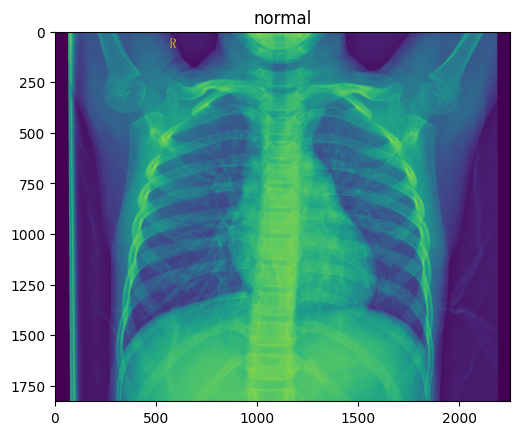

In [149]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES [int(prediction [0] [0])])
plt.show()